In [4]:
#libraries used
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

loading the data and listing all the column names 

In [15]:
df=pd.read_csv(r"PPR-ALL.csv",encoding='unicode_escape')
print(df.columns.tolist())

['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (\x80)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


In [16]:
#viewing the dataset
df

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,NaN,"343,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,NaN,"185,000.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,NaN,"438,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,04/01/2010,"1 The Haven, Mornington",Meath,NaN,"400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,NaN,"160,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
...,...,...,...,...,...,...,...,...,...
771763,13/02/2026,"CLOGHEEN, BLARNEY RD, CORK",Cork,T23Y017,"128,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
771764,13/02/2026,"DERRADA, KILLIMOR, GALWAY",Galway,H53P6D0,"130,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
771765,13/02/2026,"GARDENSTOWN, ROSCOMMON",Roscommon,N39RP40,"317,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
771766,13/02/2026,"PATRICK ST, BOYLE, CO ROSCOMMON",Roscommon,F52NP70,"65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


Data preperation
change the data type of Date of Sale from string to date in the format of dd//mm/yy
changing the data type of Price from string to numeric and also removing the euro sign and comma and converting to float
creating a new column for year by extracting the year from the date of sale column

In [17]:
df['Date of Sale (dd/mm/yyyy)'] = pd.to_datetime(df['Date of Sale (dd/mm/yyyy)'],format="%d/%m/%Y")
df['Price (\x80)']=df['Price (\x80)'].str.replace('\x80','').str.replace(',','').astype(float)
df['Year'] = df['Date of Sale (dd/mm/yyyy)'].dt.year
df = df.rename(columns={df.columns[0]: 'Date', df.columns[2]: 'County', df.columns[4]: 'Price'})




we use resample("M").mean() to group by all the prices by month and apply mean on that this is done as the data was tooo noisy to plot line chart 

most of the counties follow a similar trend as Dublin where they showed an intial dowards trend in the beginging 2010 to 2012 and for some til 2014 but 2014 onwards most of counties showard a general upward trend. 

The initial decline in irish property market price was caused by "over-correction" or freefall following the bursting of a massive property bubble also knows as the irish property bubble.In 2007 the prices stabilised and then started to fall until 2010  and subsequent years following the shock effect of the Great Recession.

From 2013 onwards economic recovery period started Prices rose by an average of 4.3% in the first three months of the 2017 representing the largest three-month increase in two years. 

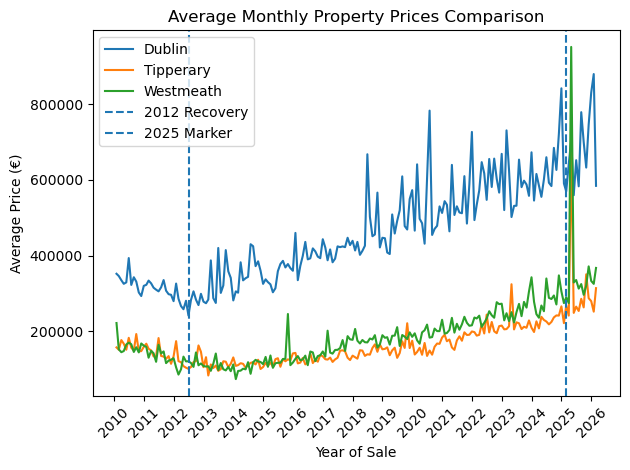

In [22]:
for county in ["Dublin", "Tipperary", "Westmeath"]:
    filtered_df = df[df['County'] == county]
    filtered_df = filtered_df.sort_values("Date")
    filtered_df = filtered_df.set_index("Date")
    
    monthly_price = filtered_df["Price"].resample("M").mean()
    
    plt.plot(monthly_price, label=county)

# Axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Reference lines
ax.axvline(x=pd.to_datetime("2012-07-01"), linestyle='--', label='2012 Recovery')
ax.axvline(x=pd.to_datetime("2025-03-01"), linestyle='--', label='2025 Marker')

plt.ylabel("Average Price (€)")
plt.xlabel("Year of Sale")
plt.title("Average Monthly Property Prices Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

“Westmeath and Tipperary display price anomalies in between 2025 and 2026, where average transaction values exceed €600,000. on further analysis of the underlying transactions suggests that these spikes may be influenced by a relatively small number of high-value or larger multi-bedroom property sales.

“Are VAT labels consistent across counties for new dwellings?”

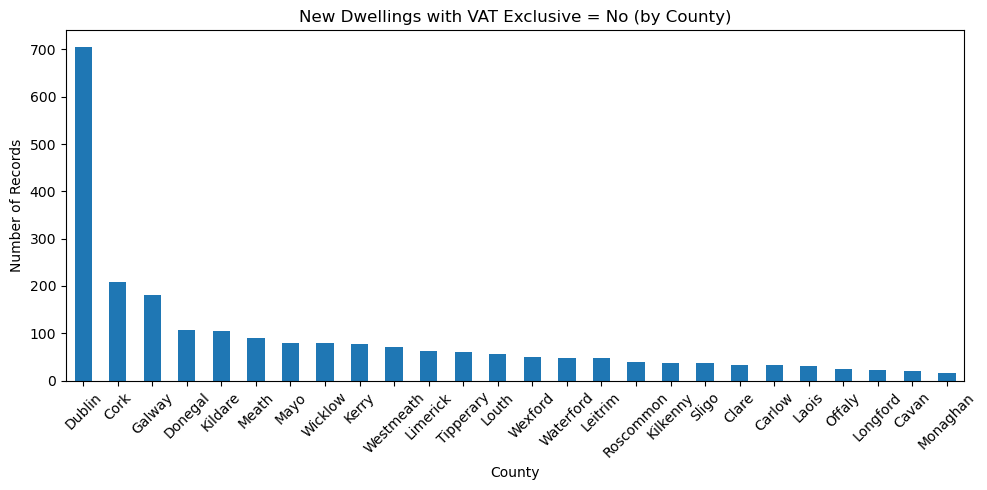

In [9]:
vat_df=df[(df["Description of Property"]=="New Dwelling house /Apartment") & (df["VAT Exclusive"] == "No")]
county_count = vat_df["County"].value_counts()
plt.figure(figsize=(10,5))

county_count.plot(kind="bar")

plt.title("New Dwellings with VAT Exclusive = No (by County)")
plt.xlabel("County")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

while new properties are expected to be recorded as VAT exclusive a notable number of records in the dataset shows vat exclusive = no. This is not an error but the different methods on how the transaction is recorded. This variation could influence price comparisons and aggregation, and it provides a justification for any furhter data-cleaning if required.

number of sales based on the decription of property along the years 

In [10]:
sales_df=df[((df["Description of Property"]=="New Dwelling house /Apartment") | (df["Description of Property"]=="Second-Hand Dwelling house /Apartment")) & (df["Year"]!=2026)].groupby(["Year","Description of Property"]).size().unstack(fill_value=0)
sales_df.head()

Description of Property,New Dwelling house /Apartment,Second-Hand Dwelling house /Apartment
Year,,
2010,5312,15687
2011,2954,15486
2012,3173,22195
2013,3893,26325
2014,5422,38248


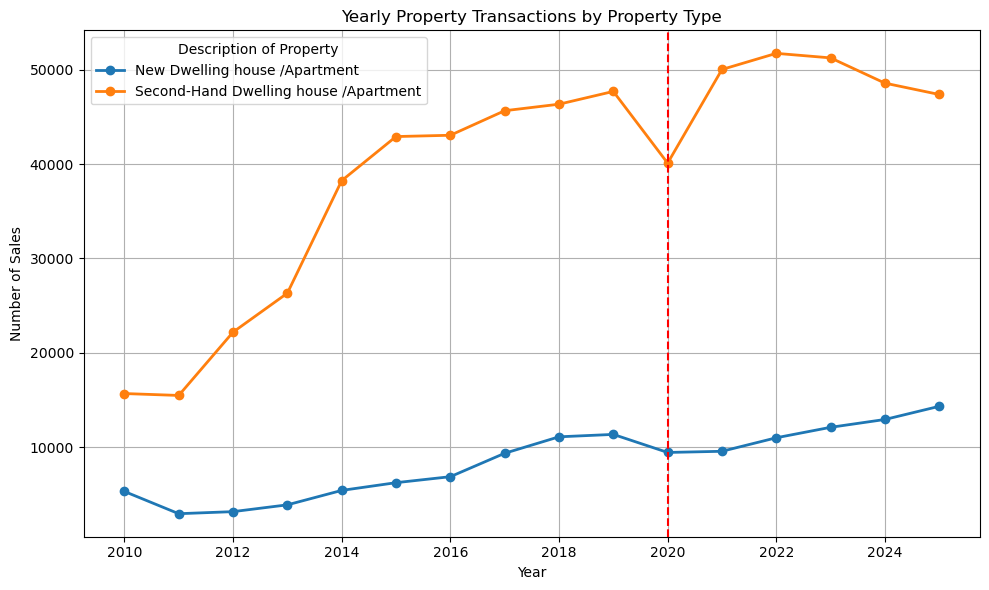

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
sales_df.plot(ax=ax, marker='o', linewidth=2)
ax.set_title("Yearly Property Transactions by Property Type")
ax.axvline(x=2020, color='red', linestyle='--', label="COVID-19 Pandemic Start")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Sales")
ax.grid(True)
plt.tight_layout()
plt.show()

the yearly property transactions based on tyes of properties  shows a genral upward trend a small drop in the year 2020 which was caused by a global pandemic and then the markter stabilized and continued tp go up in the following years.